# Pool-Ball Detection — YOLOv11 (8-Ball dataset)

Training and validating a **YOLOv11** detector on the **8-Ball Pool** dataset, treating every label
as a single **`ball`** class (detection + localization + counting).

The pipeline is split into clear stages, one per section:

1. **Setup & config** — imports, paths, hyper-parameters.
2. **Dataset split** — load the Roboflow COCO labels, collapse to one class, make a
   deterministic 70/15/15 train/val/test split, write the YOLO folder layout.
3. **Training** — fine-tune `yolo11s` from its COCO-pretrained checkpoint.
4. **Validation** — score the best checkpoint on the held-out **test** split.
5. **Metrics & graphs** — summary table, training curves, PR / F1 / confusion-matrix
   plots, and a few qualitative predictions.

> Tuned for a 6 GB GPU (RTX 3060).

## 1 · Setup & configuration

In [ ]:
import os
# Reduce CUDA fragmentation on the small 6 GB GPU (set before torch is imported).
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import json, random, shutil, contextlib, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import torch
from ultralytics import YOLO


warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 0 if torch.cuda.is_available() else "cpu"     # 0 = first CUDA GPU

def find_repo():
    p = Path.cwd().resolve()
    for q in [p, *p.parents]:
        if (q / "datasets").is_dir():
            return q
    return p

REPO     = find_repo()
DATA_DIR = REPO / "datasets" / "8-Ball Pool.v3i.coco" / "train"   # only a train/ split ships
WORK     = REPO / "task3" / "_yolo8ball"                          # prepared YOLO dataset
RUNS     = REPO / "task3" / "runs_yolo"                           # training / val outputs

# ---- hyper-parameters ----
MODEL_CKPT = "yolo11s.pt"
EPOCHS     = 50
IMGSZ      = 640
BATCH      = 8
WORKERS    = 2

print("repo  :", REPO)
print("device:", "cuda" if DEVICE == 0 else "cpu",
      "|", torch.cuda.get_device_name(0) if DEVICE == 0 else "")

repo  : /home/felipe/Desktop/facul/MS2/VC/CV_project
device: cpu | 


## 2 · Dataset split → single-class YOLO layout

The 8-Ball set ships with only a `train/` folder, so we make our own deterministic
**70/15/15** train/val/test split. Every remaining label (`Black, Cue, Solid, Striped`) is collapsed to one
**`ball`** class (id `0`); the **`Dot`** category — the table's spots, not real
balls — is excluded via `IGNORE_CATS`. Images are **symlinked** (not
copied) and labels are written as YOLO-normalized `cx cy w h`.

In [ ]:
IGNORE_CATS = {3}
coco = json.load(open(DATA_DIR / "_annotations.coco.json"))
anns_by_img = {}
for a in coco["annotations"]:
    if a["category_id"] in IGNORE_CATS:
        continue
    anns_by_img.setdefault(a["image_id"], []).append(a)

# Deterministic shuffle + 70/15/15 split.
imgs = list(coco["images"])
random.Random(SEED).shuffle(imgs)
n = len(imgs); n_tr = int(0.70 * n); n_va = int(0.15 * n)
splits = {"train": imgs[:n_tr], "val": imgs[n_tr:n_tr + n_va], "test": imgs[n_tr + n_va:]}

# (Re)build the YOLO folder: images/<split> (symlinks) + labels/<split>/*.txt
if WORK.exists():
    shutil.rmtree(WORK)
for sp, ims in splits.items():
    (WORK / "images" / sp).mkdir(parents=True, exist_ok=True)
    (WORK / "labels" / sp).mkdir(parents=True, exist_ok=True)
    for im in ims:
        fn = os.path.basename(im["file_name"])
        with contextlib.suppress(FileExistsError):
            os.symlink((DATA_DIR / im["file_name"]).resolve(), WORK / "images" / sp / fn)
        W, H = im["width"], im["height"]
        lines = []
        for a in anns_by_img.get(im["id"], []):
            x, y, w, h = a["bbox"]                      # COCO xywh (top-left)
            lines.append(f"0 {(x+w/2)/W:.6f} {(y+h/2)/H:.6f} {w/W:.6f} {h/H:.6f}")
        (WORK / "labels" / sp / (os.path.splitext(fn)[0] + ".txt")).write_text("\n".join(lines))

# YOLO dataset descriptor.
YAML = WORK / "data.yaml"
YAML.write_text(
    f"path: {WORK.resolve()}\n"
    "train: images/train\nval: images/val\ntest: images/test\n"
    "nc: 1\nnames: ['ball']\n")

for sp, ims in splits.items():
    nb = sum(len(anns_by_img.get(im["id"], [])) for im in ims)
    print(f"{sp:5s}: {len(ims):3d} images, {nb:4d} balls")
print("data.yaml ->", YAML)

train: 172 images, 1989 balls
val  :  37 images,  428 balls
test :  38 images,  400 balls
data.yaml -> /home/felipe/Desktop/facul/MS2/VC/CV_project/task3/_yolo8ball/data.yaml


### 2.1 · Sanity check — draw ground-truth boxes
Confirms the remap + split produced correctly aligned boxes before training.

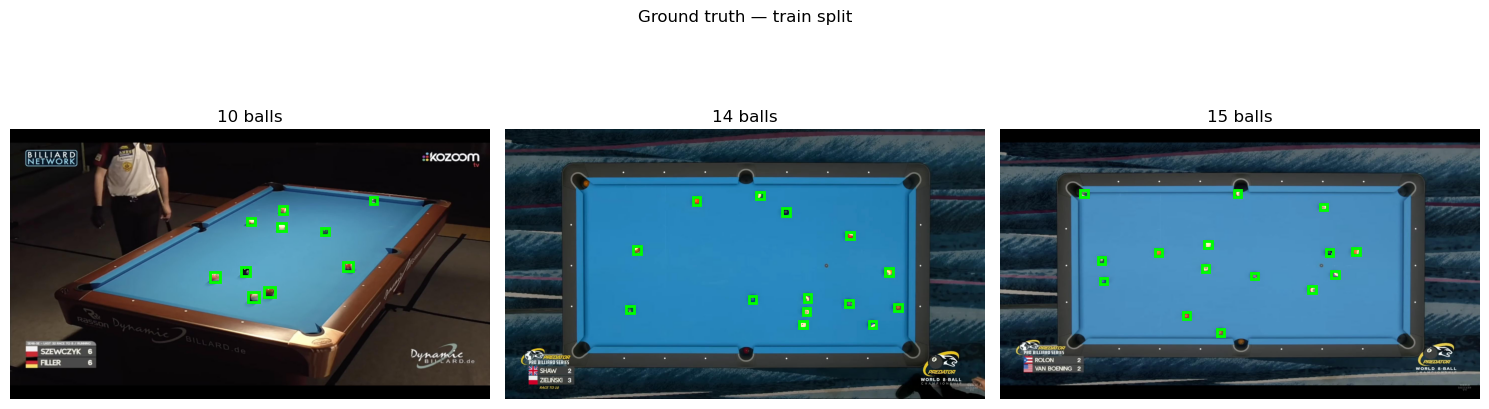

In [ ]:
def show_gt(split="train", n=3):
    ims = splits[split][:n]
    fig, axes = plt.subplots(1, len(ims), figsize=(5 * len(ims), 5))
    if len(ims) == 1: axes = [axes]
    for ax, im in zip(axes, ims):
        ax.imshow(Image.open(DATA_DIR / im["file_name"]).convert("RGB"))
        for a in anns_by_img.get(im["id"], []):
            x, y, w, h = a["bbox"]
            ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, color="lime", lw=2))
        ax.set_title(f'{len(anns_by_img.get(im["id"], []))} balls'); ax.axis("off")
    fig.suptitle(f"Ground truth — {split} split"); plt.tight_layout(); plt.show()

show_gt("train")

## 3 · Training — fine-tune YOLOv11s

Start from the COCO-pretrained `yolo11s` checkpoint and fine-tune on our `train` split.
Ultralytics validates on the `val` split every epoch and writes weights + plots to
`runs_yolo/`. `plots=True` produces the curves we display in section 5.

In [ ]:
model = YOLO(MODEL_CKPT)
model.train(
    data=str(YAML), epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH,
    seed=SEED, device=DEVICE, workers=WORKERS, plots=True, verbose=False,
    project=str(RUNS), name="yolo11s_8ball", exist_ok=True,
)
SAVE_DIR = Path(model.trainer.save_dir)
print("training done — artifacts in:", SAVE_DIR)
print("best weights:", SAVE_DIR / "weights" / "best.pt")

New https://pypi.org/project/ultralytics/8.4.80 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.79 🚀 Python-3.11.5 torch-2.12.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 5804MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/felipe/Desktop/facul/MS2/VC/CV_project/task3/_yolo8ball/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mi

## 4 · Validation — evaluate on the held-out test split

Load the **best** checkpoint and score it on the `test` split (images the model never
saw during training or per-epoch validation), so the numbers are an honest estimate.

In [6]:
SAVE_DIR = Path("/home/felipe/Desktop/facul/MS2/VC/CV_project/task3/runs_yolo/yolo11s_8ball")
best = SAVE_DIR / "weights" / "best.pt"
val_model = YOLO(str(best))
metrics = val_model.val(
    data=str(YAML), split="test", imgsz=IMGSZ, batch=BATCH, device=DEVICE,
    plots=True, project=str(RUNS), name="yolo11s_8ball_test", exist_ok=True,
)
TEST_DIR = Path(metrics.save_dir)
print(f"test mAP@0.50      : {metrics.box.map50:.4f}")
print(f"test mAP@[.50:.95] : {metrics.box.map:.4f}")
print(f"test precision     : {metrics.box.mp:.4f}")
print(f"test recall        : {metrics.box.mr:.4f}")

Ultralytics 8.4.79 🚀 Python-3.11.5 torch-2.12.1+cu130 CPU (12th Gen Intel Core i7-12700H)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4631.4±1822.8 MB/s, size: 143.7 KB)
val: Scanning /home/felipe/Desktop/facul/MS2/VC/CV_project/task3/_yolo8ball/labels/test... 38 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 38/38 2.8Kit/s 0.0s
val: New cache created: /home/felipe/Desktop/facul/MS2/VC/CV_project/task3/_yolo8ball/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.7it/s 2.9s0.8s
                   all         38        400      0.989       0.98      0.985      0.833
Speed: 0.3ms preprocess, 62.7ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/felipe/Desktop/facul/MS2/VC/CV_project/task3/runs_yolo/yolo11s_8ball_test
test mAP@0.50      : 0.9847
test mAP@[.50:.95] : 0.8334
test precision  

## 5 · Metrics & graphs

### 5.1 · Summary metrics (test split)

In [7]:
p, r = metrics.box.mp, metrics.box.mr
summary = pd.DataFrame([{
    "mAP@0.50":      metrics.box.map50,
    "mAP@[.50:.95]": metrics.box.map,
    "precision":     p,
    "recall":        r,
    "F1":            2 * p * r / (p + r + 1e-9),
}], index=["YOLOv11s (test)"]).round(4)
summary

,mAP@0.50,mAP@[.50:.95],precision,recall,F1
YOLOv11s (test),0.9847,0.8334,0.9888,0.98,0.9844


### 5.2 · Training curves
Loss and validation mAP across epochs, read from the run's `results.csv`.

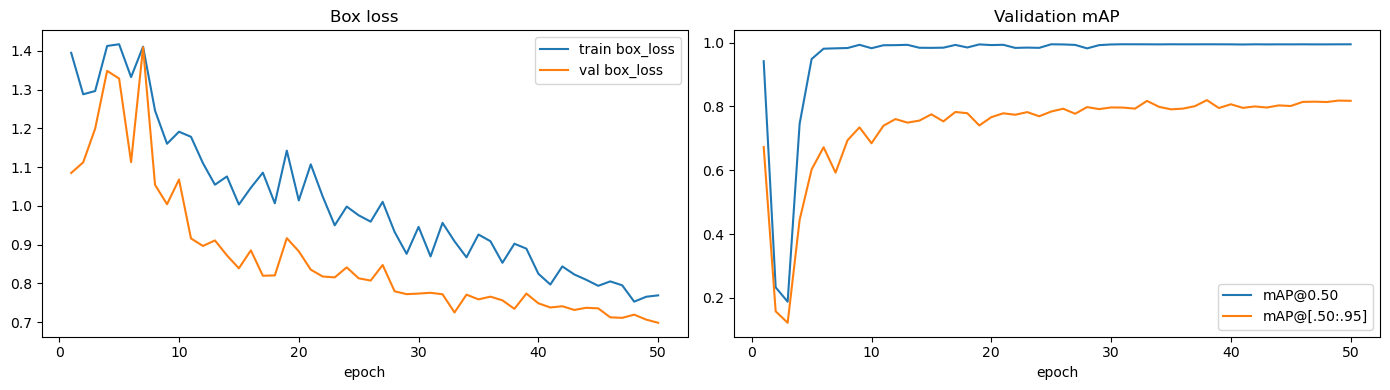

In [8]:
hist = pd.read_csv(SAVE_DIR / "results.csv")
hist.columns = [c.strip() for c in hist.columns]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(hist["epoch"], hist["train/box_loss"], label="train box_loss")
ax[0].plot(hist["epoch"], hist["val/box_loss"],   label="val box_loss")
ax[0].set_xlabel("epoch"); ax[0].set_title("Box loss"); ax[0].legend()
ax[1].plot(hist["epoch"], hist["metrics/mAP50(B)"],    label="mAP@0.50")
ax[1].plot(hist["epoch"], hist["metrics/mAP50-95(B)"], label="mAP@[.50:.95]")
ax[1].set_xlabel("epoch"); ax[1].set_title("Validation mAP"); ax[1].legend()
plt.tight_layout(); plt.show()

### 5.3 · Diagnostic plots (test split)
Precision-recall, F1-vs-confidence and confusion matrix that Ultralytics saved during validation.

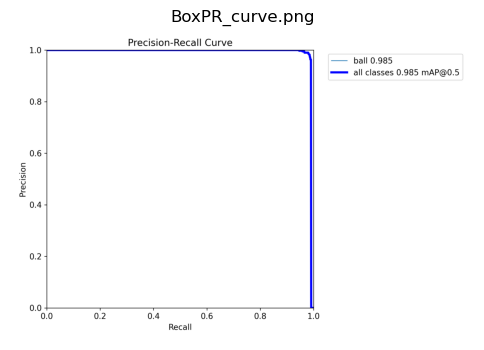

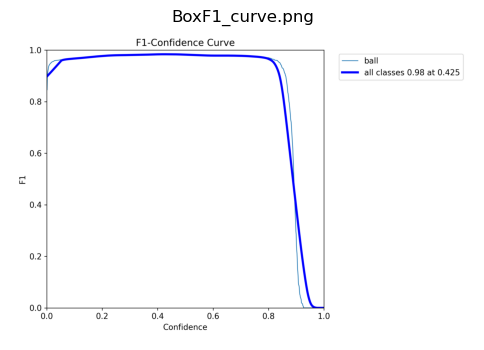

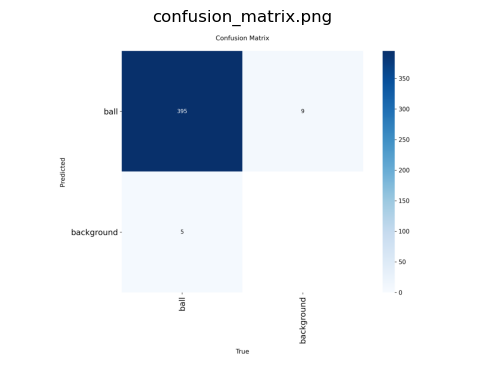

In [9]:
for name in ["BoxPR_curve.png", "BoxF1_curve.png", "confusion_matrix.png"]:
    path = TEST_DIR / name
    if path.exists():
        plt.figure(figsize=(6, 5))
        plt.imshow(mpimg.imread(path)); plt.axis("off"); plt.title(name)
        plt.show()

### 5.4 · Qualitative predictions
The trained detector on a few test images (confidence ≥ 0.25).

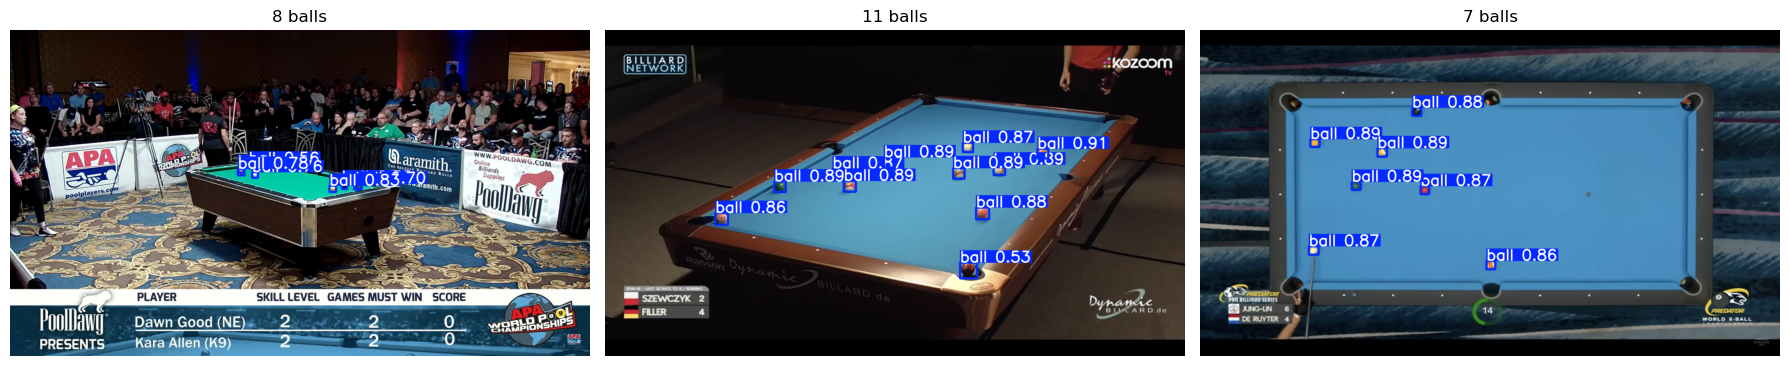

In [11]:
test_imgs = sorted((WORK / "images" / "test").glob("*"))[:3]
preds = val_model.predict([str(p) for p in test_imgs], imgsz=IMGSZ,
                          conf=0.25, device=DEVICE, verbose=False)
fig, axes = plt.subplots(1, len(preds), figsize=(6 * len(preds), 5))
if len(preds) == 1: axes = [axes]
for ax, res in zip(axes, preds):
    ax.imshow(res.plot()[..., ::-1])          # Ultralytics returns BGR -> flip to RGB
    ax.set_title(f"{len(res.boxes)} balls"); ax.axis("off")
plt.tight_layout(); plt.show()

# 6 · DETR — transformer detector (same pipeline)

Same four stages as YOLO, now for **DETR** (`facebook/detr-resnet-50`, Hugging Face): a
transformer encoder/decoder that predicts a fixed set of boxes with bipartite matching.
It reuses the **same 70/15/15 split** (`splits`, `anns_by_img`) built in section 2, so the
comparison is apples-to-apples.

Unlike Ultralytics, DETR has no built-in metric/plot tooling, so we add a tiny shared
**evaluation harness** — COCO mAP via `pycocotools`, precision/recall/F1 via greedy IoU
matching — producing the exact same numbers and graphs we showed for YOLO.

> Tuned for 6 GB: small input size, batch 2 with gradient accumulation (effective 8), AMP.
> DETR converges slowly — the training cell is the slow part; lower `DETR_EPOCHS` to test.

## 6.1 · Dataset for DETR

DETR consumes COCO-style targets. We (a) write a single-class COCO **ground-truth** JSON
per split for `pycocotools`, and (b) wrap the split in a `Dataset` that yields
`(PIL image, COCO target)` for the Hugging Face image processor.

In [12]:
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm


DETR_DIR = REPO / "task3" / "_detr8ball"
DETR_DIR.mkdir(parents=True, exist_ok=True)

def build_coco_gt(split):
    # COCO dict with a single 'ball' category (id=1) -> ground truth for pycocotools.
    ims = splits[split]
    anns = []
    for im in ims:
        for a in anns_by_img.get(im["id"], []):
            x, y, w, h = a["bbox"]
            anns.append({"id": len(anns) + 1, "image_id": im["id"], "category_id": 1,
                         "bbox": [x, y, w, h], "area": w * h, "iscrowd": 0})
    d = {"images": ims, "annotations": anns, "categories": [{"id": 1, "name": "ball"}]}
    p = DETR_DIR / f"{split}.json"
    json.dump(d, open(p, "w"))
    return p, d

GT = {sp: build_coco_gt(sp) for sp in ["train", "val", "test"]}   # GT[sp] = (json_path, dict)

class DetrDataset(Dataset):
    # Yields (PIL image, COCO target) for the HF processor.
    # Single class -> category index 0 (model has num_labels=1); COCO eval keeps id=1.
    def __init__(self, split):
        self.ims = [im for im in splits[split] if anns_by_img.get(im["id"])]
    def __len__(self):
        return len(self.ims)
    def __getitem__(self, i):
        im = self.ims[i]
        image = Image.open(DATA_DIR / im["file_name"]).convert("RGB")
        anns = [{"image_id": im["id"], "category_id": 0, "bbox": a["bbox"],
                 "area": a["bbox"][2] * a["bbox"][3], "iscrowd": 0}
                for a in anns_by_img.get(im["id"], [])]
        return image, {"image_id": im["id"], "annotations": anns}

print("single-class COCO GT written to", DETR_DIR)
for sp in ["train", "val", "test"]:
    print(f"  {sp:5s}: {len(GT[sp][1]['images']):3d} images, {len(GT[sp][1]['annotations']):4d} balls")

single-class COCO GT written to /home/felipe/Desktop/facul/MS2/VC/CV_project/task3/_detr8ball
  train: 172 images, 1989 balls
  val  :  37 images,  428 balls
  test :  38 images,  400 balls


## 6.2 · Training — fine-tune DETR-R50

Load the COCO-pretrained DETR with a fresh 1-class head and fine-tune with AdamW + AMP +
gradient accumulation. We track mean loss per epoch (plotted in 6.4) and `save_pretrained`
the result so a restart doesn't force a retrain.

`tqdm` (not `tqdm.auto`) is used on purpose — the widget version was the source of the
earlier `widget-view` render error.

In [18]:
from transformers import DetrForObjectDetection, DetrImageProcessor
from tqdm import tqdm

DETR_CKPT   = "facebook/detr-resnet-50"
DETR_EPOCHS = 40
DETR_BATCH  = 2
DETR_ACCUM  = 4                       # effective batch = 8
DETR_LR     = 1e-4
DETR_SHORT, DETR_LONG = 480, 800      # smaller than default so activations fit 6 GB

processor = DetrImageProcessor.from_pretrained(
    DETR_CKPT, size={"shortest_edge": DETR_SHORT, "longest_edge": DETR_LONG})
detr = DetrForObjectDetection.from_pretrained(
    DETR_CKPT, num_labels=1, ignore_mismatched_sizes=True).to(DEVICE)

def collate(batch):
    # The processor pads images and converts boxes to the normalized cxcywh DETR expects.
    return processor(images=[b[0] for b in batch],
                     annotations=[b[1] for b in batch], return_tensors="pt")

dl = DataLoader(DetrDataset("train"), batch_size=DETR_BATCH, shuffle=True,
                collate_fn=collate, num_workers=WORKERS)
opt = torch.optim.AdamW(detr.parameters(), lr=DETR_LR, weight_decay=1e-4)
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == 0))

detr.train()
detr_loss_hist = []
for ep in range(DETR_EPOCHS):
    opt.zero_grad(); running = 0.0
    for i, enc in enumerate(tqdm(dl, desc=f"epoch {ep+1}/{DETR_EPOCHS}", leave=False)):
        batch = {}
        for k, v in enc.items():
            batch[k] = (v.to(DEVICE) if torch.is_tensor(v)
                        else [{kk: vv.to(DEVICE) for kk, vv in t.items()} for t in v])
        with torch.amp.autocast("cuda", enabled=(DEVICE == 0)):
            loss = detr(**batch).loss / DETR_ACCUM
        scaler.scale(loss).backward()
        running += loss.item() * DETR_ACCUM
        if (i + 1) % DETR_ACCUM == 0:
            scaler.step(opt); scaler.update(); opt.zero_grad()
    detr_loss_hist.append(running / len(dl))
    print(f"epoch {ep+1:2d}/{DETR_EPOCHS}  loss={detr_loss_hist[-1]:.4f}")

DETR_SAVE = RUNS / "detr_8ball"
detr.save_pretrained(DETR_SAVE); processor.save_pretrained(DETR_SAVE)
json.dump(detr_loss_hist, open(DETR_SAVE / "loss_history.json", "w"))  # persist the loss curve
print("DETR saved to", DETR_SAVE)

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were not initialized from the model checkpoin

epoch  1/40  loss=1.8523


epoch 2/40:   0%|          | 0/86 [00:00<?, ?it/s]The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


epoch  2/40  loss=1.5364


epoch 3/40:   0%|          | 0/86 [00:00<?, ?it/s]The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


...

epoch 38/40  loss=1.1927


epoch 39/40:   0%|          | 0/86 [00:00<?, ?it/s]The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


epoch 39/40  loss=1.2736


epoch 40/40:   0%|          | 0/86 [00:00<?, ?it/s]The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


epoch 40/40  loss=1.2504
DETR saved to /home/felipe/Desktop/facul/MS2/VC/CV_project/task3/runs_yolo/detr_8ball


## 6.3 · Validation — evaluate on the held-out test split

Run DETR over every test image, rescale boxes back to original pixels, and score with the
shared harness: **COCO mAP** (`pycocotools`) + **precision/recall/F1** at a fixed
confidence. Same four numbers as the YOLO section.

In [13]:
import io as _io
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from transformers import DetrForObjectDetection, DetrImageProcessor

# Load the fine-tuned DETR from disk so validation runs WITHOUT re-executing the slow
# training cell (mirrors the YOLO validation cell, which loads best.pt from disk).
DETR_SAVE = Path("/home/felipe/Desktop/facul/MS2/VC/CV_project/task3/runs_yolo/detr_8ball")
processor = DetrImageProcessor.from_pretrained(str(DETR_SAVE))
detr = DetrForObjectDetection.from_pretrained(str(DETR_SAVE)).to(DEVICE)

DETR_CONF = 0.7          # confidence used for P/R/F1 (mAP itself is threshold-free)

def _iou_xywh(boxes, gts):
    # Vectorised IoU between two sets of [x,y,w,h] boxes -> matrix [len(boxes), len(gts)].
    if len(boxes) == 0 or len(gts) == 0:
        return np.zeros((len(boxes), len(gts)))
    b = np.asarray(boxes, float); g = np.asarray(gts, float)
    ix1 = np.maximum(b[:, 0][:, None], g[:, 0][None, :])
    iy1 = np.maximum(b[:, 1][:, None], g[:, 1][None, :])
    ix2 = np.minimum((b[:, 0] + b[:, 2])[:, None], (g[:, 0] + g[:, 2])[None, :])
    iy2 = np.minimum((b[:, 1] + b[:, 3])[:, None], (g[:, 1] + g[:, 3])[None, :])
    inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
    union = (b[:, 2] * b[:, 3])[:, None] + (g[:, 2] * g[:, 3])[None, :] - inter
    return inter / np.clip(union, 1e-9, None)

def prf1(results, gt_dict, conf, iou_thr=0.5):
    # Greedy one-to-one matching per image at a fixed confidence -> (P, R, F1).
    gt_by, dt_by = {}, {}
    for a in gt_dict["annotations"]:
        gt_by.setdefault(a["image_id"], []).append(a["bbox"])
    for r in results:
        if r["score"] >= conf:
            dt_by.setdefault(r["image_id"], []).append((r["bbox"], r["score"]))
    TP = FP = FN = 0
    for im in gt_dict["images"]:
        gts = gt_by.get(im["id"], [])
        dts = sorted(dt_by.get(im["id"], []), key=lambda x: -x[1])
        iou = _iou_xywh([d[0] for d in dts], gts); matched = set()
        for di in range(len(dts)):
            best, bj = iou_thr, -1
            for gj in range(len(gts)):
                if gj not in matched and iou[di, gj] >= best:
                    best, bj = iou[di, gj], gj
            if bj >= 0: TP += 1; matched.add(bj)
            else:       FP += 1
        FN += len(gts) - len(matched)
    P = TP / (TP + FP) if TP + FP else 0.0
    R = TP / (TP + FN) if TP + FN else 0.0
    return P, R, (2 * P * R / (P + R) if P + R else 0.0)

@torch.no_grad()
def detr_infer(image):
    # Returns [(x, y, w, h, score), ...] in ORIGINAL image pixels (threshold 0 keeps all).
    detr.eval()
    enc = processor(images=image, return_tensors="pt").to(DEVICE)
    out = detr(**enc)
    sizes = torch.tensor([[image.height, image.width]]).to(DEVICE)
    res = processor.post_process_object_detection(out, target_sizes=sizes, threshold=0.0)[0]
    return [(float(x1), float(y1), float(x2 - x1), float(y2 - y1), float(s))
            for (x1, y1, x2, y2), s in zip(res["boxes"].cpu().numpy(), res["scores"].cpu().numpy())]

# inference over the test split -> COCO-format detections
detr_results = []
for im in tqdm(splits["test"], desc="DETR test inference", leave=False):
    image = Image.open(DATA_DIR / im["file_name"]).convert("RGB")
    for (x, y, w, h, s) in detr_infer(image):
        detr_results.append({"image_id": im["id"], "category_id": 1,
                             "bbox": [x, y, w, h], "score": s})

# COCO mAP (silenced) + P/R/F1
gt_coco = COCO(str(GT["test"][0]))
with contextlib.redirect_stdout(_io.StringIO()):
    dt = gt_coco.loadRes(detr_results)
    E = COCOeval(gt_coco, dt, "bbox"); E.evaluate(); E.accumulate(); E.summarize()
detr_map50_95, detr_map50 = float(E.stats[0]), float(E.stats[1])
detr_P, detr_R, detr_F1 = prf1(detr_results, GT["test"][1], DETR_CONF)

print(f"test mAP@0.50      : {detr_map50:.4f}")
print(f"test mAP@[.50:.95] : {detr_map50_95:.4f}")
print(f"test precision     : {detr_P:.4f}")
print(f"test recall        : {detr_R:.4f}")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
test mAP@0.50      : 0.6639
test mAP@[.50:.95] : 0.2132
test precision     : 0.6227
test recall        : 0.7550


## 6.4 · Metrics & graphs

### 6.4.1 · Summary metrics (test split) + comparison with YOLO

In [14]:
detr_summary = pd.DataFrame([{
    "mAP@0.50": detr_map50, "mAP@[.50:.95]": detr_map50_95,
    "precision": detr_P, "recall": detr_R, "F1": detr_F1,
}], index=["DETR-R50 (test)"]).round(4)

# Stack on top of the YOLO row if section 5 was run in this session.
try:
    comparison = pd.concat([summary, detr_summary])
except NameError:
    comparison = detr_summary
comparison

,mAP@0.50,mAP@[.50:.95],precision,recall,F1
YOLOv11s (test),0.9847,0.8334,0.9888,0.980,0.9844
DETR-R50 (test),0.6639,0.2132,0.6227,0.755,0.6825


### 6.4.2 · Training loss curve

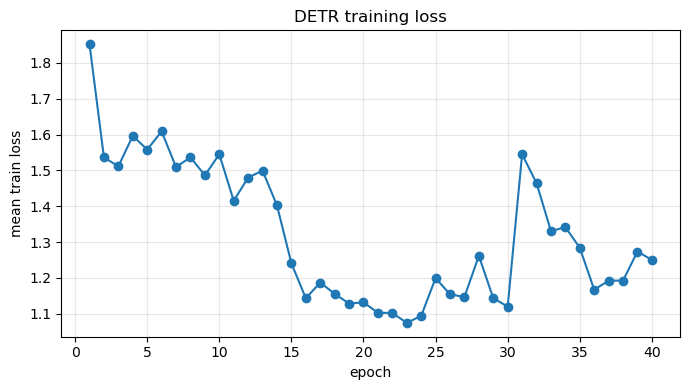

In [15]:
# Use the in-memory history if training just ran; otherwise load the saved copy from disk
# (recovered without re-training the model).
try:
    _loss = detr_loss_hist
except NameError:
    _loss = json.load(open(RUNS / "detr_8ball" / "loss_history.json"))

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(_loss) + 1), _loss, marker="o")
plt.xlabel("epoch"); plt.ylabel("mean train loss"); plt.title("DETR training loss")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### 6.4.3 · Precision-recall & F1-vs-confidence
Swept over confidence thresholds at IoU 0.5 (DETR has no built-in PR plot, so we compute it).

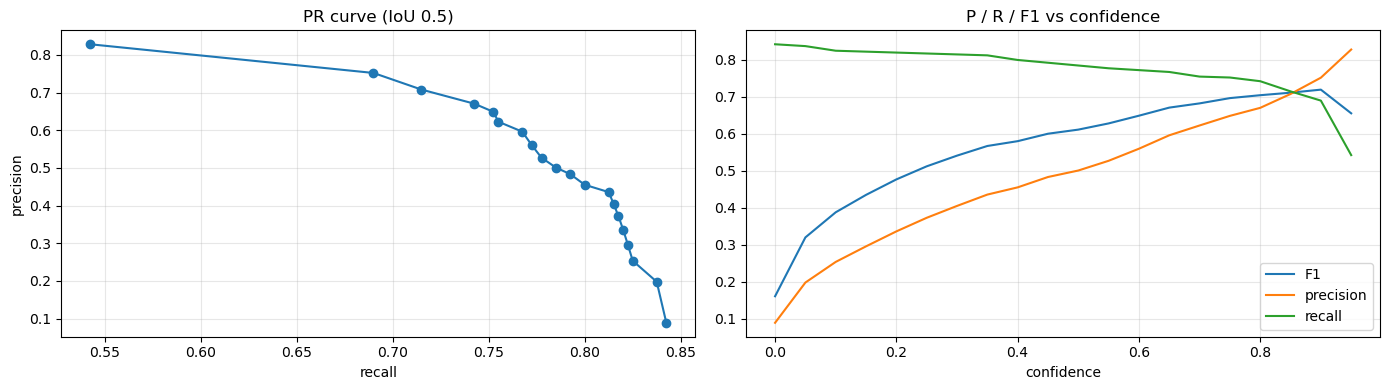

best F1 = 0.7197 at confidence = 0.90


In [16]:
threshs = np.linspace(0.0, 0.95, 20)
Ps, Rs, F1s = zip(*[(lambda t: prf1(detr_results, GT["test"][1], t))(t) for t in threshs])

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(Rs, Ps, marker="o"); ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision")
ax[0].set_title("PR curve (IoU 0.5)"); ax[0].grid(alpha=0.3)
ax[1].plot(threshs, F1s, label="F1"); ax[1].plot(threshs, Ps, label="precision")
ax[1].plot(threshs, Rs, label="recall")
ax[1].set_xlabel("confidence"); ax[1].set_title("P / R / F1 vs confidence")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

best = int(np.argmax(F1s))
print(f"best F1 = {F1s[best]:.4f} at confidence = {threshs[best]:.2f}")

### 6.4.4 · Qualitative predictions
DETR detections (confidence ≥ `DETR_CONF`) on a few test images.

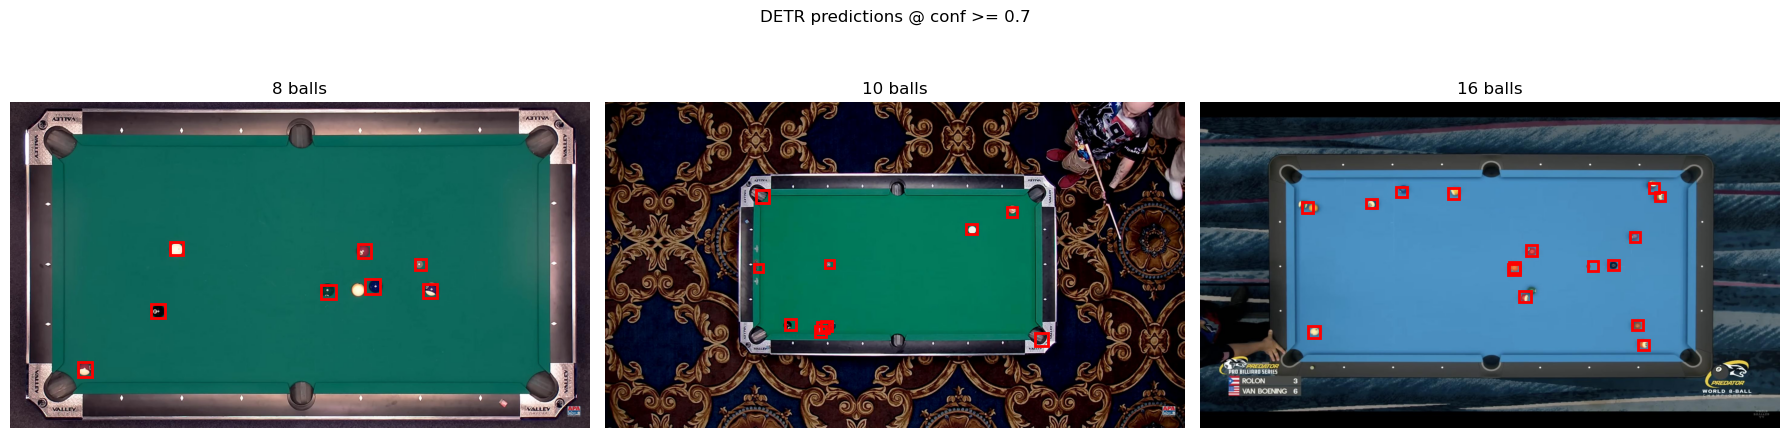

In [17]:
test_imgs = splits["test"][:3]
fig, axes = plt.subplots(1, len(test_imgs), figsize=(6 * len(test_imgs), 5))
if len(test_imgs) == 1: axes = [axes]
for ax, im in zip(axes, test_imgs):
    image = Image.open(DATA_DIR / im["file_name"]).convert("RGB")
    ax.imshow(image)
    dets = [d for d in detr_infer(image) if d[4] >= DETR_CONF]
    for (x, y, w, h, s) in dets:
        ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, color="red", lw=2))
    ax.set_title(f"{len(dets)} balls"); ax.axis("off")
plt.suptitle(f"DETR predictions @ conf >= {DETR_CONF}"); plt.tight_layout(); plt.show()

# 7 · Quantitative comparison — YOLOv11 vs DETR

Both detectors were trained on the same `train` split and scored on the same held-out
`test` split through the same metrics, so these numbers are directly comparable. The table
collects every metric; the bar chart shows them side by side. Parameter counts are added as
a rough capacity / cost indicator.

,mAP@0.50,mAP@[.50:.95],precision,recall,F1,params (M)
YOLOv11s,0.9847,0.8334,0.9888,0.980,0.9844,9.4132
DETR-R50,0.6639,0.2132,0.6227,0.755,0.6825,41.5016


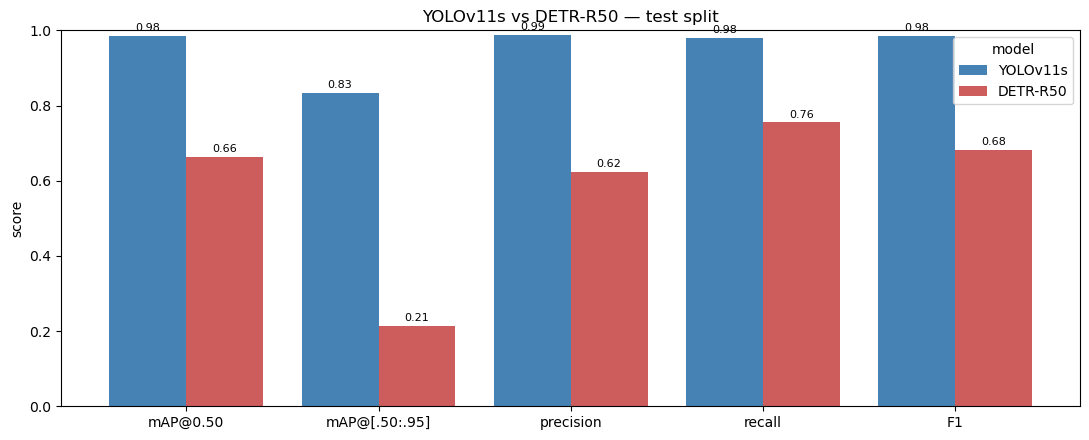

Winner by metric:
  mAP@0.50      : YOLOv11s  (0.985 vs 0.664)
  mAP@[.50:.95] : YOLOv11s  (0.833 vs 0.213)
  precision     : YOLOv11s  (0.989 vs 0.623)
  recall        : YOLOv11s  (0.980 vs 0.755)
  F1            : YOLOv11s  (0.984 vs 0.682)


In [18]:
# YOLO numbers come from the val results object `metrics` (section 4);
# DETR numbers from the `detr_*` variables (section 6.3).
yp, yr = metrics.box.mp, metrics.box.mr
rows = {
    "YOLOv11s": {"mAP@0.50": metrics.box.map50, "mAP@[.50:.95]": metrics.box.map,
                 "precision": yp, "recall": yr, "F1": 2 * yp * yr / (yp + yr + 1e-9)},
    "DETR-R50": {"mAP@0.50": detr_map50, "mAP@[.50:.95]": detr_map50_95,
                 "precision": detr_P, "recall": detr_R, "F1": detr_F1},
}

# Optional: parameter counts if the models are still resident in the kernel.
def _params(getter):
    try:    return sum(p.numel() for p in getter()) / 1e6
    except Exception: return float("nan")
rows["YOLOv11s"]["params (M)"] = _params(lambda: val_model.model.parameters())
rows["DETR-R50"]["params (M)"] = _params(lambda: detr.parameters())

compare = pd.DataFrame(rows).T.round(4)
display(compare)

# Grouped bar chart over the quality metrics (params shown separately given its scale).
quality = ["mAP@0.50", "mAP@[.50:.95]", "precision", "recall", "F1"]
ax = compare[quality].T.plot.bar(figsize=(11, 4.5), rot=0, width=0.8,
                                 color={"YOLOv11s": "steelblue", "DETR-R50": "indianred"})
ax.set_title("YOLOv11s vs DETR-R50 — test split")
ax.set_ylabel("score"); ax.set_ylim(0, 1); ax.legend(title="model")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=2, fontsize=8)
plt.tight_layout(); plt.show()

# One-line takeaway per metric (which model wins).
print("Winner by metric:")
for m in quality:
    a, b = compare.loc["YOLOv11s", m], compare.loc["DETR-R50", m]
    win = "YOLOv11s" if a > b else ("DETR-R50" if b > a else "tie")
    print(f"  {m:14s}: {win:9s} ({a:.3f} vs {b:.3f})")